# Test RMTS vs. Kriging on RANS data

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from scipy.interpolate import make_smoothing_spline
from smt.surrogate_models import RMTB, RMTC, KRG

plt.rcParams["figure.figsize"] = (7, 4.5)

# Font sizes scaled up from matplotlib's defaults (10pt @ 100dpi) because the
# comparison plots below are rendered much wider (up to figsize=(18,5) for
# triplets, 6*n_models wide for grid comparisons) -- at default font sizes,
# labels/legends/titles end up a small fraction of the image and look tiny
# once the wide image is scaled down to fit a notebook/markdown viewer.
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 18,
})

In [2]:
DEG2RAD = np.pi / 180.0
RAD2DEG = 180.0 / np.pi

## Load and prepare the data

In [3]:
rans_df = pd.read_csv("../data/rans_data.csv")
raw_data = rans_df.to_numpy()
colnames = rans_df.columns.tolist()

In [4]:
rans_df

,alpha,mach,cd,cl,cmx,cmy,cmz
0,2.00,0.45,0.015368,0.367424,0.559228,-0.125804,-0.012487
1,3.50,0.45,0.019851,0.490447,0.757460,-0.161526,0.008987
2,5.00,0.45,0.025710,0.610919,0.949795,-0.195462,0.040909
3,6.50,0.45,0.033042,0.726612,1.131139,-0.225589,0.081854
4,8.00,0.45,0.043190,0.824725,1.271487,-0.239704,0.121766
5,0.00,0.58,0.011362,0.204876,0.295028,-0.078821,-0.022801
6,1.50,0.58,0.014260,0.337562,0.511413,-0.118942,-0.015882
7,3.00,0.58,0.018664,0.468745,0.724040,-0.157767,0.003100
8,4.50,0.58,0.024620,0.597664,0.931171,-0.194416,0.033575
9,6.00,0.58,0.032807,0.714225,1.111708,-0.220587,0.071517


## Utility functions

In [5]:
def get_rans_crm_wing():
    # data structure:
    # alpha, mach, cd, cl, cmx, cmy, cmz

    deg2rad = np.pi / 180.0

    xt = np.array(raw_data[:, 0:2])
    yt = np.array(raw_data[:, 2:4])
    xlimits = np.array([[-3.0, 10.0], [0.4, 0.90]])

    xt[:, 0] *= deg2rad
    xlimits[0, :] *= deg2rad

    return xt, yt, xlimits

In [6]:
# ---------------------------------------------------------------------------
# Prediction (no matplotlib here)
# ---------------------------------------------------------------------------

def _predict(model, alpha_deg, mach):
    """Evaluate a single-output model at broadcastable alpha (deg) / Mach arrays."""
    alpha_deg, mach = np.broadcast_arrays(np.asarray(alpha_deg, float),
                                          np.asarray(mach, float))
    x = np.column_stack([alpha_deg.ravel() * DEG2RAD, mach.ravel()])
    y = model.predict_values(x)
    if y.ndim == 2 and y.shape[1] != 1:
        raise ValueError(f"Expected a single-output model, got {y.shape[1]} outputs")
    return y.ravel().reshape(alpha_deg.shape)


def predict_alpha_sweeps(model, mach_numbers, alpha_deg):
    """Return {mach: y(alpha)} for each Mach number."""
    return {m: _predict(model, alpha_deg, m) for m in mach_numbers}


def predict_mach_sweeps(model, alphas_deg, mach):
    """Return {alpha_deg: y(mach)} for each angle of attack."""
    return {a: _predict(model, a, mach) for a in alphas_deg}


def predict_grid(model, alpha_deg, mach):
    """Return (ALPHA_deg, MACH, Y) meshgrids, shape (len(alpha), len(mach))."""
    A, M = np.meshgrid(alpha_deg, mach, indexing="ij")
    return A, M, _predict(model, A, M)

In [7]:
# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_alpha_sweeps(ax, alpha_deg, sweeps, xt=None, yt=None, label="y"):
    for (mach, y), color in zip(sweeps.items(), plt.cm.tab10.colors):
        ax.plot(alpha_deg, y, color=color, label=f"M={mach}")
        if xt is not None:
            mask = np.isclose(xt[:, 1], mach)
            ax.plot(xt[mask, 0] * RAD2DEG, yt[mask], "o", color=color)
    
    ax.set(xlabel="alpha (deg)", ylabel=label)
    ax.legend()


def plot_mach_sweeps(ax, mach, sweeps, xt=None, yt=None, label="y", alpha_tol=1e-2):
    """Training points are shown where |alpha_data - alpha_sweep| <= alpha_tol (deg)."""
    for (alpha, y), color in zip(sweeps.items(), plt.cm.tab10.colors):
        ax.plot(mach, y, color=color, label=f"alpha={alpha}°")
        if xt is not None:
            mask = np.abs(xt[:, 0] * RAD2DEG - alpha) <= alpha_tol
            ax.plot(xt[mask, 1], yt[mask], "o", color=color)
    
    ax.set(xlabel="Mach number", ylabel=label)
    ax.legend()


def plot_contour(ax, A, M, Y, xt=None, label="y", levels=20):
    pcm = ax.pcolormesh(M, A, Y, cmap="rainbow", shading="auto")
    ax.contour(M, A, Y, levels, colors="k", linewidths=0.5)
    if xt is not None:
        ax.plot(xt[:, 1], xt[:, 0] * RAD2DEG, "ko", markersize=3)
    ax.figure.colorbar(pcm, ax=ax)
    ax.set(xlabel="Mach number", ylabel="alpha (deg)", title=label)


In [8]:
def plot_alpha_sweeps_compare(ax, alpha_deg, sweeps_by_model, xt=None, yt=None, label="y"):
    """sweeps_by_model: {model_label: {mach: y(alpha)}}, i.e. predict_alpha_sweeps
    run once per model. Color = Mach condition (as in plot_alpha_sweeps),
    linestyle = model."""
    linestyles = ["-", "--", ":", "-."]
    machs = list(next(iter(sweeps_by_model.values())).keys())
    colors = dict(zip(machs, plt.cm.tab10.colors))

    for mind, (model_label, sweeps) in enumerate(sweeps_by_model.items()):
        ls = linestyles[mind % len(linestyles)]
        for mach, y in sweeps.items():
            ax.plot(alpha_deg, y, ls, color=colors[mach])

    if xt is not None:
        for mach, color in colors.items():
            mask = np.isclose(xt[:, 1], mach)
            ax.plot(xt[mask, 0] * RAD2DEG, yt[mask], "o", color=color)

    ax.set(xlabel="alpha (deg)", ylabel=label)
    cond_handles = [Line2D([0], [0], color=c, marker="o", label=f"M={m}") for m, c in colors.items()]
    model_handles = [Line2D([0], [0], color="0.2", linestyle=linestyles[i % len(linestyles)], label=lbl)
                      for i, lbl in enumerate(sweeps_by_model.keys())]
    leg1 = ax.legend(handles=cond_handles, loc="upper left", title="condition")
    ax.add_artist(leg1)
    ax.legend(handles=model_handles, loc="upper right", title="model")


def plot_mach_sweeps_compare(ax, mach, sweeps_by_model, xt=None, yt=None, label="y", alpha_tol=1e-2):
    """sweeps_by_model: {model_label: {alpha_deg: y(mach)}}. Color = alpha
    condition, linestyle = model."""
    linestyles = ["-", "--", ":", "-."]
    alphas = list(next(iter(sweeps_by_model.values())).keys())
    colors = dict(zip(alphas, plt.cm.tab10.colors))

    for mind, (model_label, sweeps) in enumerate(sweeps_by_model.items()):
        ls = linestyles[mind % len(linestyles)]
        for alpha, y in sweeps.items():
            ax.plot(mach, y, ls, color=colors[alpha])

    if xt is not None:
        for alpha, color in colors.items():
            mask = np.abs(xt[:, 0] * RAD2DEG - alpha) <= alpha_tol
            ax.plot(xt[mask, 1], yt[mask], "o", color=color)

    ax.set(xlabel="Mach number", ylabel=label)
    cond_handles = [Line2D([0], [0], color=c, marker="o", label=f"alpha={a}°") for a, c in colors.items()]
    model_handles = [Line2D([0], [0], color="0.2", linestyle=linestyles[i % len(linestyles)], label=lbl)
                      for i, lbl in enumerate(sweeps_by_model.keys())]
    leg1 = ax.legend(handles=cond_handles, loc="upper left", title="condition")
    ax.add_artist(leg1)
    ax.legend(handles=model_handles, loc="upper right", title="model")


def rmse_table(xt, y_true, models):
    """models: {label: fitted single-output model}. Training RMSE per model."""
    print(f"{'model':<20}{'RMSE':>14}")
    for label, model in models.items():
        pred = model.predict_values(xt)
        r = np.sqrt(np.mean((pred.ravel() - y_true.ravel()) ** 2))
        print(f"{label:<20}{r:>14.3e}")


def plot_sweep_comparison(models, alpha_deg, mach, alphas_deg, mach_numbers, xt, y_resp, label):
    """models: {label: fitted single-output model}. Alpha-sweep overlay and
    Mach-sweep overlay, side by side -- all models superimposed, color =
    condition, linestyle = model. Also prints the training-RMSE table."""
    alpha_sweeps = {lbl: predict_alpha_sweeps(m, mach_numbers, alpha_deg) for lbl, m in models.items()}
    mach_sweeps = {lbl: predict_mach_sweeps(m, alphas_deg, mach) for lbl, m in models.items()}

    fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    plot_alpha_sweeps_compare(axs[0], alpha_deg, alpha_sweeps, xt, y_resp, label)
    plot_mach_sweeps_compare(axs[1], mach, mach_sweeps, xt, y_resp, label)
    fig.suptitle(f"{label} -- sweep comparison")
    plt.show()

    rmse_table(xt, y_resp, models)


def plot_grid_comparison(models, alpha_grid, mach_grid, xt, label):
    """models: {label: fitted single-output model}. One contour panel per
    model, side by side (reuses plot_contour as-is, one call per model)."""
    grids = {}
    A = M = None
    for lbl, m in models.items():
        A, M, Y = predict_grid(m, alpha_grid, mach_grid)
        grids[lbl] = Y

    n_models = len(models)
    fig, axs = plt.subplots(1, n_models, figsize=(6 * n_models, 5), constrained_layout=True)
    if n_models == 1:
        axs = [axs]
    for ax, (lbl, Y) in zip(axs, grids.items()):
        plot_contour(ax, A, M, Y, xt, f"{label}: {lbl}")
    fig.suptitle(f"{label} -- 2-D comparison")
    plt.show()

## Prepare Training Datasets

2D case studied here - Cd(alph, mach), Cl(alpha, mach)

In [9]:
# common input variables are used for both Cd and Cl
xt = rans_df[["alpha", "mach"]].to_numpy()
xt[:, 0] *= DEG2RAD
# xt

In [10]:
alpha_lims = np.array([-3.0, 10.0])*DEG2RAD
mach_lims = np.array([0.4, 0.90])
xlimits = np.array([alpha_lims, mach_lims])
xlimits

array([[-0.05235988,  0.17453293],
       [ 0.4       ,  0.9       ]])

In [11]:
# response variables
cd_resp = rans_df[["cd"]].to_numpy() # Cd response column
cl_resp = rans_df[["cl"]].to_numpy() # Cl response column

## Build models

### RMTB models for cd(alpha, mach) and cl(alpha, mach)

In [12]:
rmtb_cd = RMTB(num_ctrl_pts=20, xlimits=xlimits, nonlinear_maxiter=100, energy_weight=1e-12, print_global=False)
rmtb_cd.set_training_values(xt, cd_resp)
rmtb_cd.train()

In [13]:
rmtb_cl = RMTB(num_ctrl_pts=20, xlimits=xlimits, nonlinear_maxiter=100, energy_weight=1e-12, print_global=False)
rmtb_cl.set_training_values(xt, cl_resp)
rmtb_cl.train()

### Kriging models for cd(alpha, mach) and cl(alpha, mach)

In [14]:
krg_mt32_cd = KRG(corr="matern32", poly="linear", print_global=False)
krg_mt32_cd.set_training_values(xt, cd_resp)
krg_mt32_cd.train()

In [15]:
krg_mt32_cl = KRG(corr="matern32", poly="linear", print_global=False)
krg_mt32_cl.set_training_values(xt, cl_resp)
krg_mt32_cl.train()

In [16]:
krg_mt52_cd = KRG(corr="matern52", poly="linear", print_global=False)
krg_mt52_cd.set_training_values(xt, cd_resp)
krg_mt52_cd.train()

In [17]:
krg_mt52_cl = KRG(corr="matern52", poly="linear", print_global=False)
krg_mt52_cl.set_training_values(xt, cl_resp)
krg_mt52_cl.train()

## Predict Responses Using Trained Models

In [18]:
alpha_range = (0.0, 8.0)
mach_range = (0.45, 0.86)
alphas_deg = (2.0, 4.0, 6.0)
mach_numbers = (0.45, 0.68, 0.80, 0.86)
num_lin = 500 
num_grid = 50

alpha_line = np.linspace(*alpha_range, num_lin)
mach_line = np.linspace(*mach_range, num_lin)

### Predict Cd Values

In [19]:
RMTB_CD_alpha_sweeps = predict_alpha_sweeps(rmtb_cd, mach_numbers, alpha_line)
RMTB_CD_mach_sweeps = predict_mach_sweeps(rmtb_cd, alphas_deg, mach_line)

In [20]:
RMTB_A, RMTB_M, RMTB_CD = predict_grid(
    rmtb_cd, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid)
)

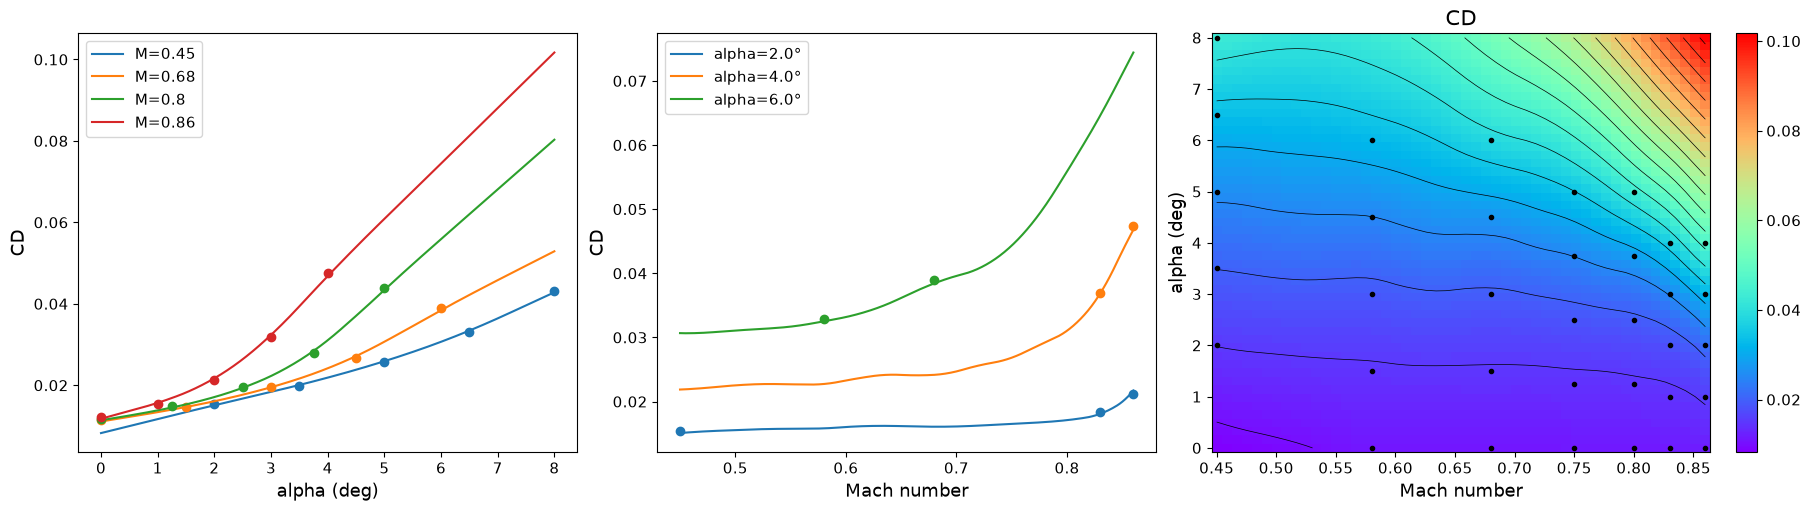

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_alpha_sweeps(axs[0], alpha_line, RMTB_CD_alpha_sweeps, xt, cd_resp, "CD")
plot_mach_sweeps(axs[1], mach_line, RMTB_CD_mach_sweeps, xt, cd_resp, "CD")
plot_contour(axs[2], RMTB_A, RMTB_M, RMTB_CD, xt, "CD")

In [22]:
krig_mt32_CD_alpha_sweeps = predict_alpha_sweeps(krg_mt32_cd, mach_numbers, alpha_line)
krig_mt32_CD_mach_sweeps = predict_mach_sweeps(krg_mt32_cd, alphas_deg, mach_line)

In [23]:
krig_mt32_A, krig_mt32_M, krig_mt32_CD = predict_grid(
    krg_mt32_cd, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid)
)

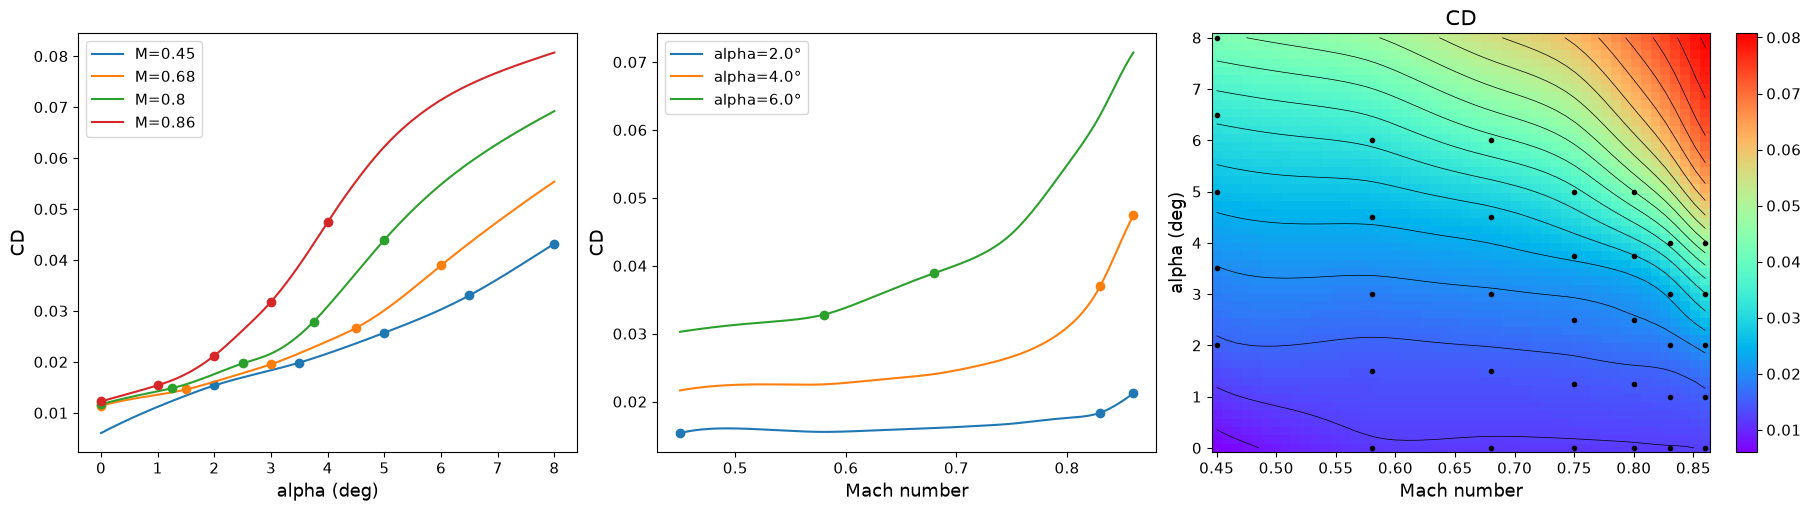

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_alpha_sweeps(axs[0], alpha_line, krig_mt32_CD_alpha_sweeps, xt, cd_resp, "CD")
plot_mach_sweeps(axs[1], mach_line, krig_mt32_CD_mach_sweeps, xt, cd_resp, "CD")
plot_contour(axs[2], krig_mt32_A, krig_mt32_M, krig_mt32_CD, xt, "CD")

In [25]:
krig_mt52_CD_alpha_sweeps = predict_alpha_sweeps(krg_mt52_cd, mach_numbers, alpha_line)
krig_mt52_CD_mach_sweeps = predict_mach_sweeps(krg_mt52_cd, alphas_deg, mach_line)

In [26]:
krig_mt52_A, krig_mt52_M, krig_mt52_CD = predict_grid(
    krg_mt52_cd, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid)
)

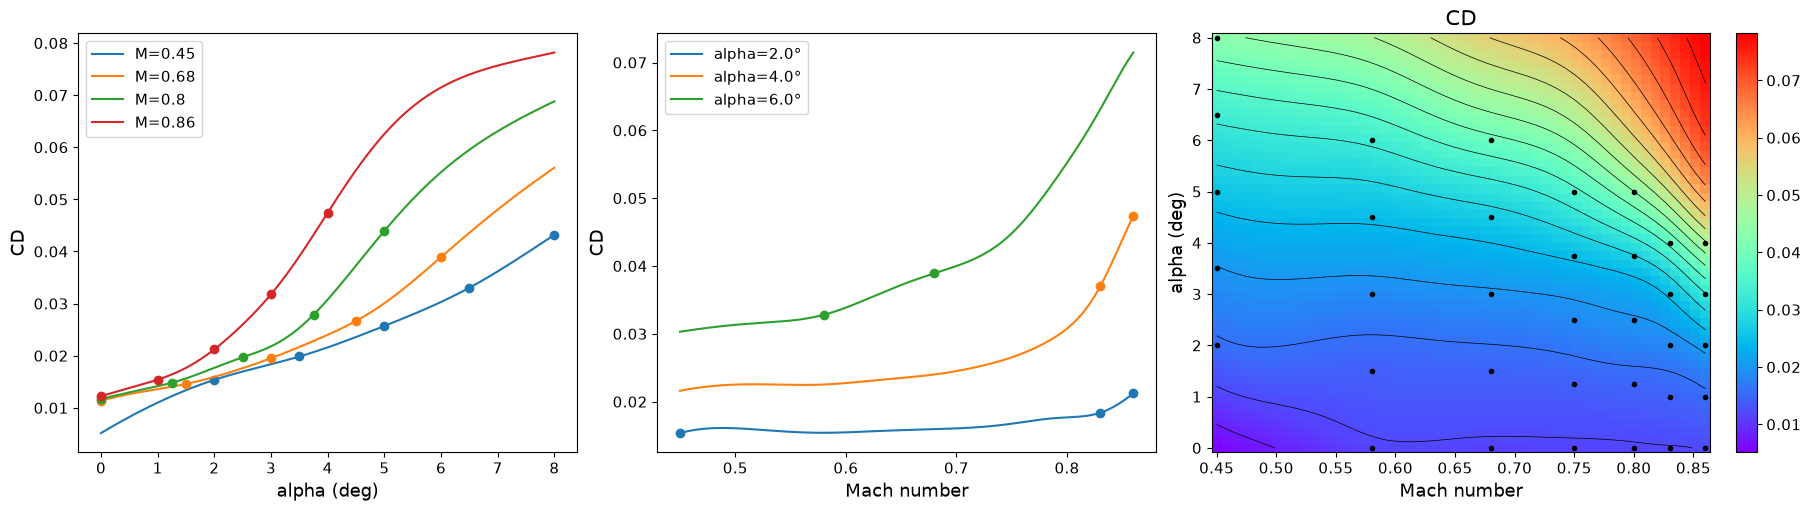

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_alpha_sweeps(axs[0], alpha_line, krig_mt52_CD_alpha_sweeps, xt, cd_resp, "CD")
plot_mach_sweeps(axs[1], mach_line, krig_mt52_CD_mach_sweeps, xt, cd_resp, "CD")
plot_contour(axs[2], krig_mt52_A, krig_mt52_M, krig_mt52_CD, xt, "CD")

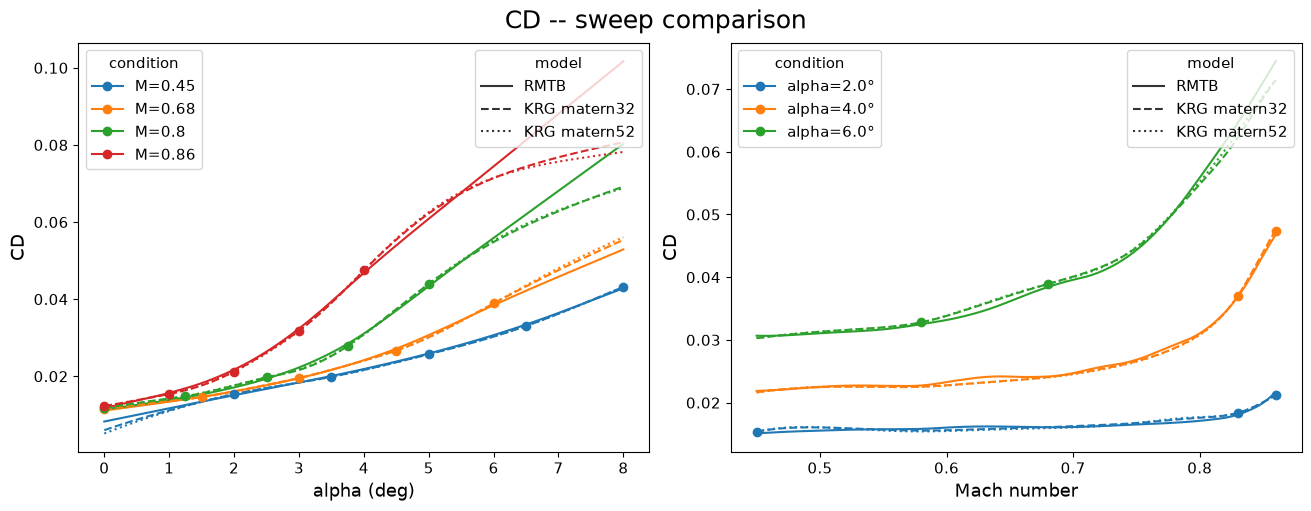

model                         RMSE
RMTB                     3.585e-04
KRG matern32             1.358e-15
KRG matern52             1.883e-15


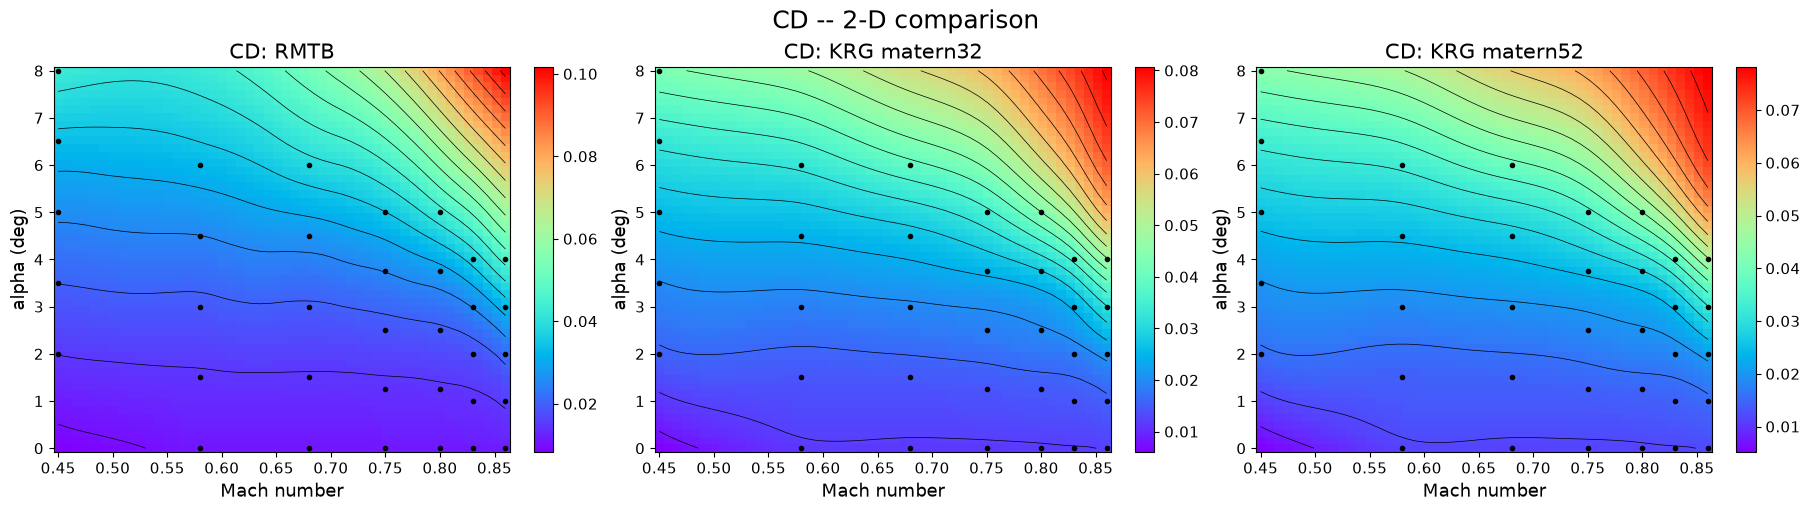

In [28]:
cd_models = {"RMTB": rmtb_cd, "KRG matern32": krg_mt32_cd, "KRG matern52": krg_mt52_cd}

plot_sweep_comparison(cd_models, alpha_line, mach_line, alphas_deg, mach_numbers, xt, cd_resp, "CD")
plot_grid_comparison(cd_models, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid), xt, "CD")

### Predict Cl Values

In [29]:
RMTB_CL_alpha_sweeps = predict_alpha_sweeps(rmtb_cl, mach_numbers, alpha_line)
RMTB_CL_mach_sweeps = predict_mach_sweeps(rmtb_cl, alphas_deg, mach_line)

In [30]:
RMTB_A, RMTB_M, RMTB_CL = predict_grid(rmtb_cl, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid))

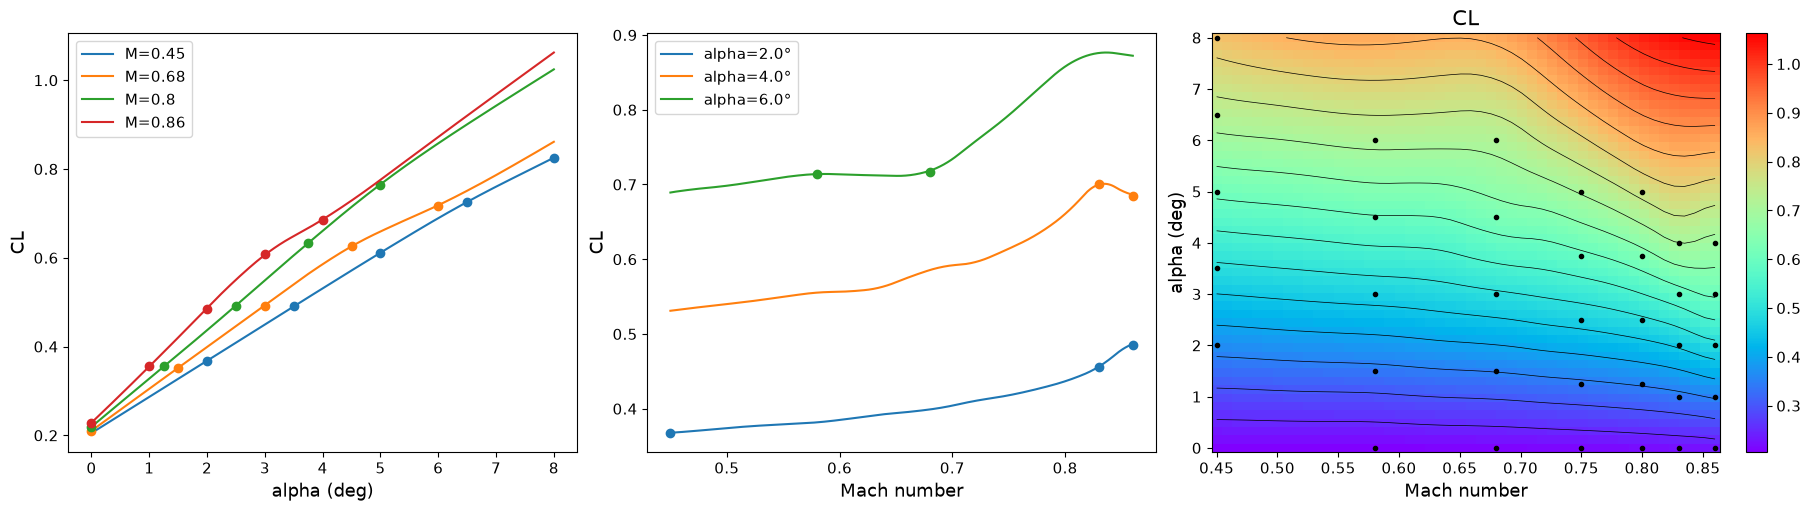

In [31]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_alpha_sweeps(axs[0], alpha_line, RMTB_CL_alpha_sweeps, xt, cl_resp, "CL")
plot_mach_sweeps(axs[1], mach_line, RMTB_CL_mach_sweeps, xt, cl_resp, "CL")
plot_contour(axs[2], RMTB_A, RMTB_M, RMTB_CL, xt, "CL")

In [32]:
krig_mt32_CL_alpha_sweeps = predict_alpha_sweeps(krg_mt32_cl, mach_numbers, alpha_line)
krig_mt32_CL_mach_sweeps = predict_mach_sweeps(krg_mt32_cl, alphas_deg, mach_line)

In [33]:
krig_mt32_A, krig_mt32_M, krig_mt32_CL = predict_grid(
    krg_mt32_cl, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid)
)

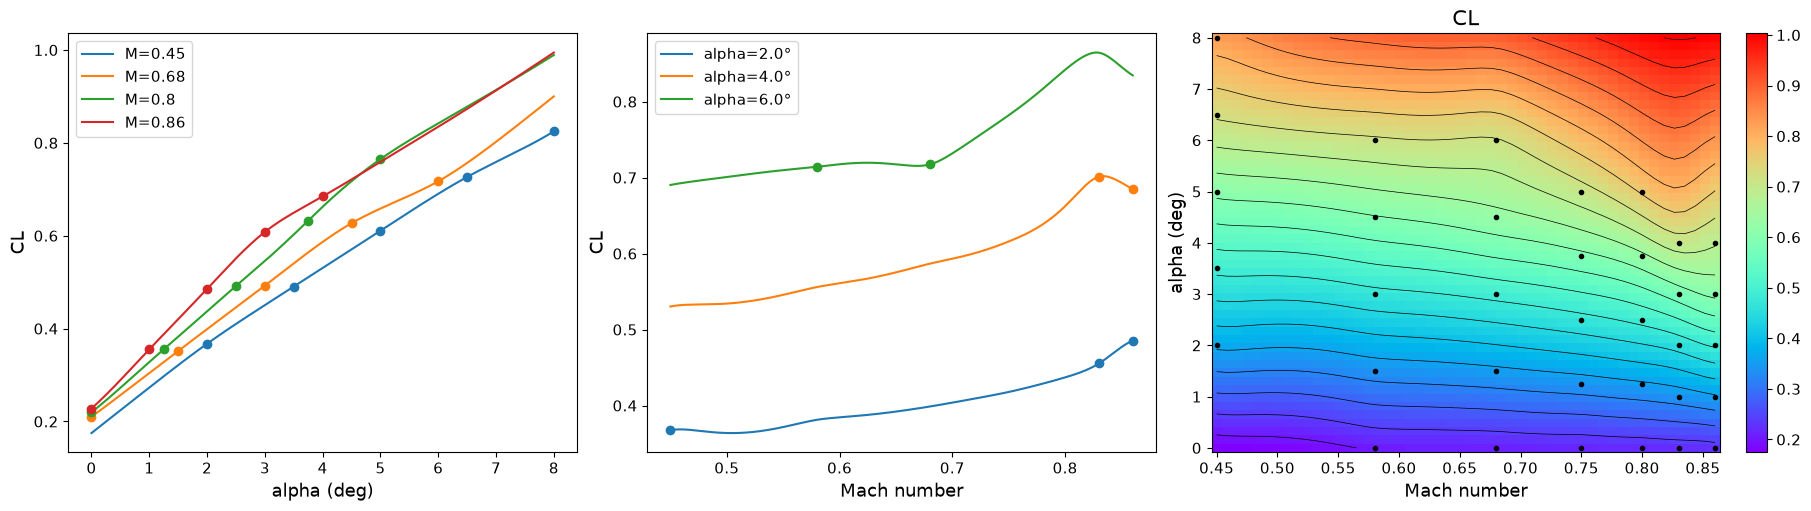

In [34]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_alpha_sweeps(axs[0], alpha_line, krig_mt32_CL_alpha_sweeps, xt, cl_resp, "CL")
plot_mach_sweeps(axs[1], mach_line, krig_mt32_CL_mach_sweeps, xt, cl_resp, "CL")
plot_contour(axs[2], krig_mt32_A, krig_mt32_M, krig_mt32_CL, xt, "CL")

In [35]:
krig_mt52_CL_alpha_sweeps = predict_alpha_sweeps(krg_mt52_cl, mach_numbers, alpha_line)
krig_mt52_CL_mach_sweeps = predict_mach_sweeps(krg_mt52_cl, alphas_deg, mach_line)

In [36]:
krig_mt52_A, krig_mt52_M, krig_mt52_CL = predict_grid(
    krg_mt52_cl, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid)
)

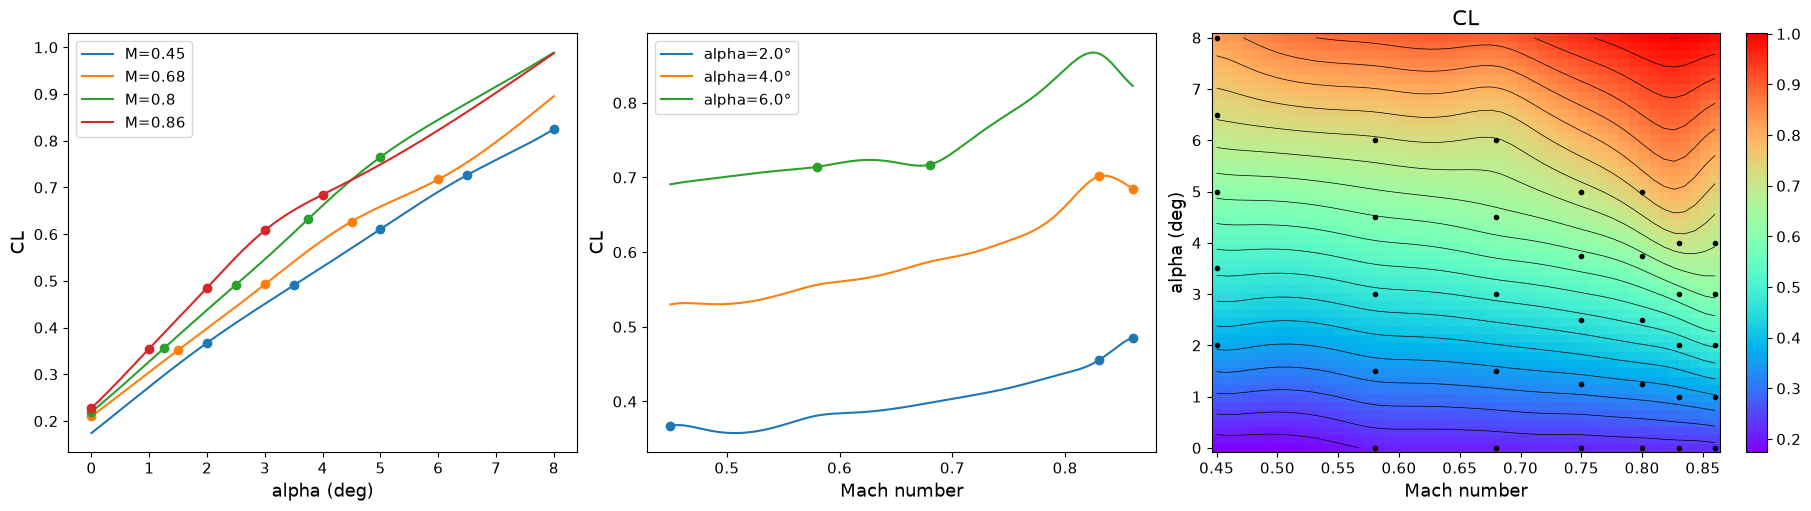

In [37]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_alpha_sweeps(axs[0], alpha_line, krig_mt52_CL_alpha_sweeps, xt, cl_resp, "CL")
plot_mach_sweeps(axs[1], mach_line, krig_mt52_CL_mach_sweeps, xt, cl_resp, "CL")
plot_contour(axs[2], krig_mt52_A, krig_mt52_M, krig_mt52_CL, xt, "CL")

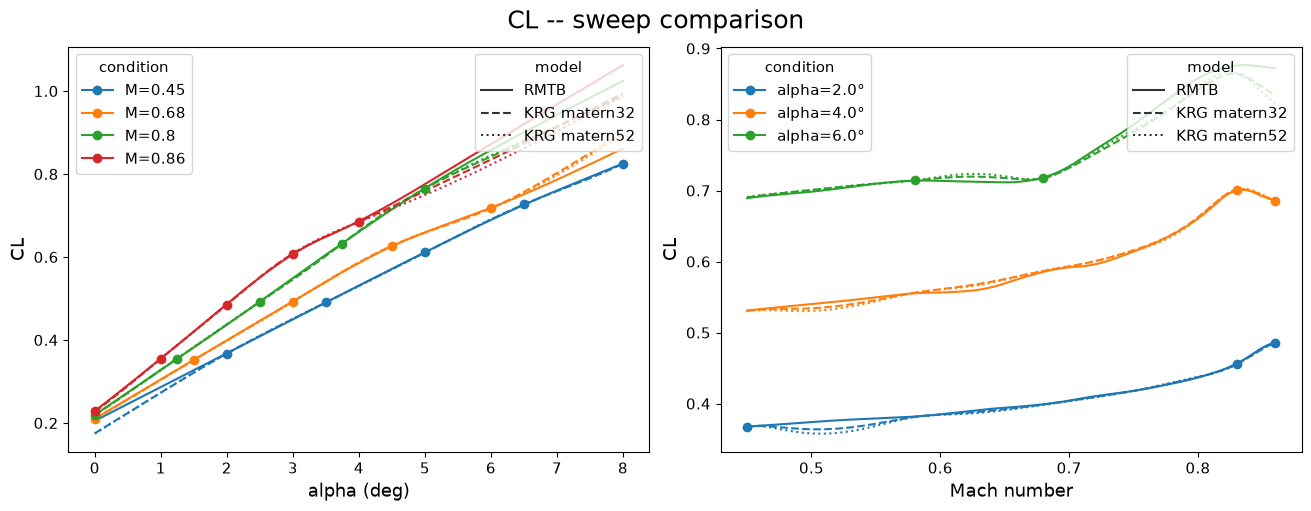

model                         RMSE
RMTB                     7.529e-04
KRG matern32             2.514e-15
KRG matern52             3.350e-15


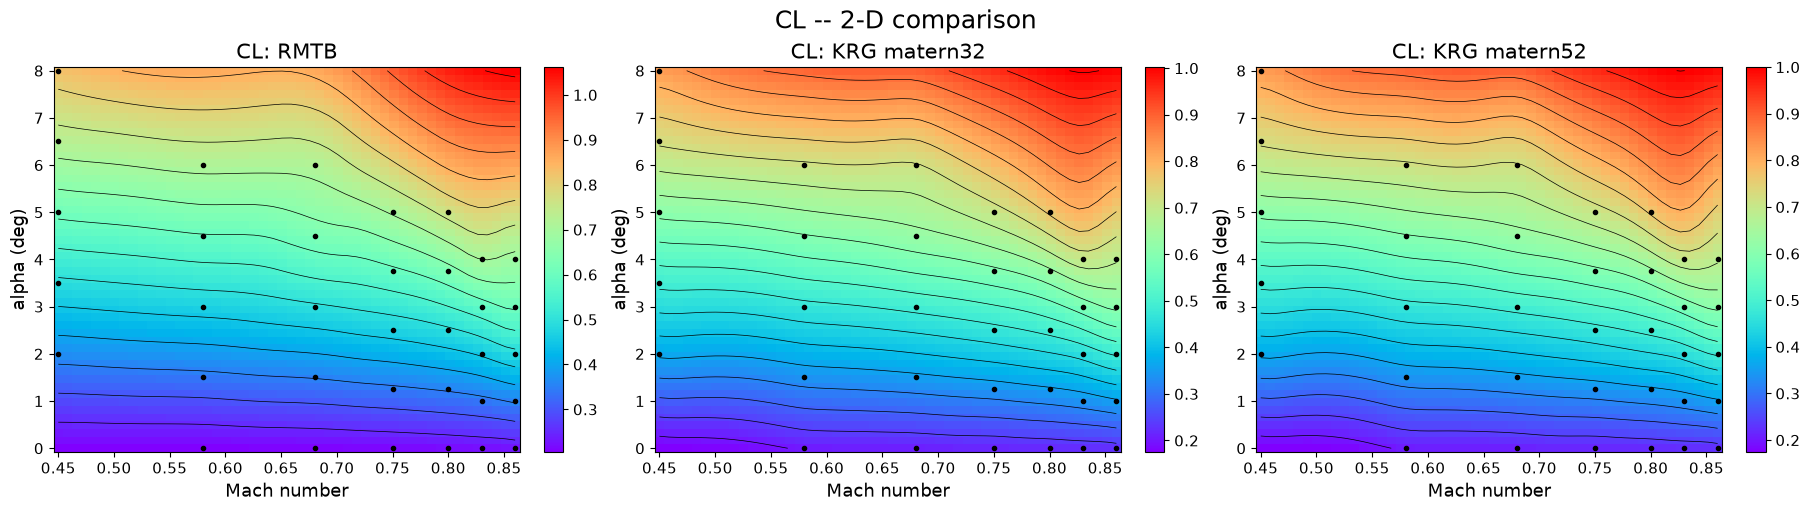

In [38]:
cl_models = {"RMTB": rmtb_cl, "KRG matern32": krg_mt32_cl, "KRG matern52": krg_mt52_cl}

plot_sweep_comparison(cl_models, alpha_line, mach_line, alphas_deg, mach_numbers, xt, cl_resp, "CL")
plot_grid_comparison(cl_models, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid), xt, "CL")